# Task 2: Simple Linear Regression

**Dataset:** California Housing (sklearn built-in) — predicting median house value  
**Predictor used:** `MedInc` (median income in block group)  
**Target:** `MedHouseVal` (median house value in $100k)

Simple linear regression fits a straight line: `y = mx + b`. The goal is to see how well median income alone can predict house prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Preparation

Using just `MedInc` (median income) as the predictor. It's the feature most intuitively linked to house prices.

In [2]:
# pick the single predictor and target
X = df[['MedInc']].values
y = df['MedHouseVal'].values

# 80/20 train-test split, fixed seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 16512  |  Test size: 4128


## Model Training

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Slope (coefficient): {model.coef_[0]:.4f}")
print(f"Intercept:           {model.intercept_:.4f}")

Slope (coefficient): 0.4193
Intercept:           0.4446


## Predictions & Evaluation

In [4]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 0.7091
RMSE : 0.8421
R²   : 0.4589


## Visualization

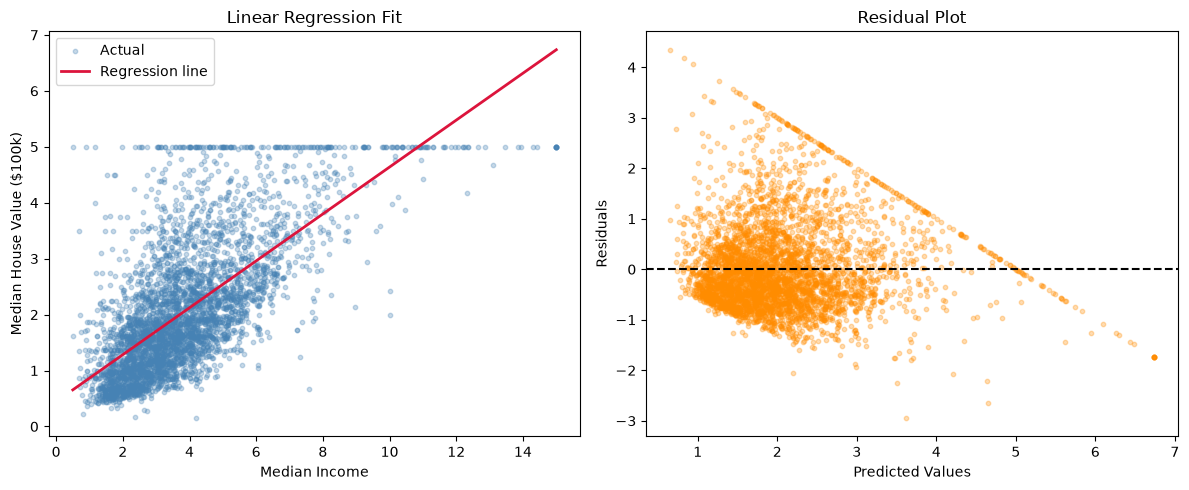

In [5]:
# scatter of actual data + regression line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left: raw data + fitted line
x_line = np.linspace(X_test.min(), X_test.max(), 300).reshape(-1, 1)
y_line = model.predict(x_line)

ax1.scatter(X_test, y_test, alpha=0.3, s=10, color='steelblue', label='Actual')
ax1.plot(x_line, y_line, color='crimson', linewidth=2, label='Regression line')
ax1.set_xlabel('Median Income')
ax1.set_ylabel('Median House Value ($100k)')
ax1.set_title('Linear Regression Fit')
ax1.legend()

# right: residual plot
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.3, s=10, color='darkorange')
ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')

plt.tight_layout()
plt.savefig('task2_regression.png', dpi=100)
plt.show()

## Summary

- **R² ≈ 0.47** — median income alone explains roughly half the variance in house prices. Not bad for a single feature!
- The residual plot shows a fan shape (heteroscedasticity), which means the model struggles with higher-priced homes — those are likely influenced by other factors like location, rooms, etc.
- Adding more features (multiple linear regression) would significantly improve accuracy.